J. L. Hopkins (z5479137)

# Import the required constants and functions

In [1108]:
# Import Libraries
import numpy as np
from scipy.linalg import eigh
import matplotlib.pyplot as plt

# Import constants
from scipy.constants import hbar, m_e, elementary_charge

def fwhm(x, y):
    half_max = np.max(y) / 2
    # find indices where y crosses half_max
    indices = np.where(y >= half_max)[0]
    return x[indices[-1]] - x[indices[0]]

m_TO_nm = 1e9
eV_TO_meV = 1e3

# Introduction

This report seeks to numerically solve both the time independent Schrodinger equation under a single quantum dot potential well (SQD), and a double quantum dot potential well (DQD) through the finite distance method. Through the analysis of these results, parameters of the potential and well spacing will be determined that allow for an effective simulation of a rabi-oscillating qubit. This oscillating qubit will be numerically solved using the Crank Nicholson method on the time dependent Schrodinger equation for both in-phase rabi-oscillations ($\omega = \omega_R$), and out of phase oscillations, ($\omega = 0.95 \omega_R$).

# Background
## 2x2 quibit Hamiltonian
Although the main focus of this report is the numeric analysis of a time independent, and time dependent Hamiltonian of a qubit, it is useful to understand that the qubit can be mapped onto the following Hamiltonian,
$$
H = \begin{bmatrix}E & t \\ t^* & E\end{bmatrix}
$$
which allows for analytical solutions for the wave-functions and their corresponding energies.

This matrix will be used in Part A to obtain a numeric solution for a qubit, and referenced throughout to tie the numeric solution methods back to an analytic solution.

## Finite difference Hamiltonian for a Metal Oxide Semi-conductor.
The time dependent Schrodinger equation is [1, 2],
$$
\hat{H} \psi(x) = E \psi(x)\\
-\frac{\hbar^2}{2m^*} \frac{\text{d} ^2 \psi(x)}{\text{d} x^2} + V(x) \psi(x) = E \psi(x)
$$

Where the following is the corresponding Hamiltonian [1, 2],
$$
\hat{H} = -\frac{\hbar^2}{2m^*} \frac{\text{d} ^2}{\text{d} x^2} + V(x) 
$$

As this report seeks to analyse the response of the wave-function over a potential domain using numerical methods, specifically the finite difference method, the Hamiltonian has to be transcribed into a $N\times N$ dimensional tri-diagonal matrix of the form,
$$
\hat{H} = \begin{bmatrix}
2t+V_1 & -t & 0 & \cdots & 0 \\
-t & 2t+V_2 & -t & \ddots & \vdots \\
0 & -t & 2t+V_3 & \ddots & 0 \\
\vdots & \ddots & \ddots & \ddots & -t \\
0 & \cdots & 0 & -t & 2t+V_N
\end{bmatrix}
$$

where $V_N$ is the potential evaluated at node N, and given a mesh spacing $a$, $t = \frac{\hbar ^2}{2ma^{*2}}$ [1, 2].

Importantly for this analysis, the quantum dots are simulated in a silicone 1D lattice, and such the electron's effective mass $m^*=0.2 m_0$, where $m_0$ is the rest mass of the electron [1]. 

By constructing this Hamiltonian for a given potential function, for example a single quantum dot (SQD) described by a parabolic potential with curvature $\alpha$ [1],
$$
V_{\text{SQD}} (x) = \alpha (x - x_1)^2
$$
or a double quantum dot (DQD), simulated as two parabolic wells centered at $x_1$ and $x_2$ with symmetric curvature $\alpha$ with a minimum potential condition, better explained by the function [1],
$$
V_{\text{DQD}} (x) = \text{min}\left[ \alpha(x-x_1)^2, \alpha(x-x_2)^2 \right]
$$
and solving for its eigen-values and eigen-vectors, each wave-function from the ground-state to the Nth state, and its corresponding energy level can be obtained, and analysed.

## Rabi Oscillations and the Time independent Hamiltonian.
Rabi oscillations are the response of a double quantum dot system with an addition linear oscillating potential of the form,
$$
V_{\text{rabi}}(x, t) = F x \cos(\omega t)
$$
where a resonant rabi oscillation has the angular velocity $\omega = \omega_R - \frac{E_1 - E_0}{\hbar}$ [1].

To analyze the DQD response under rabi oscillations, the Crank Nicholson time-stepping algorithm will be applied to the following discretized time-dependent Hamiltonian [4],
$$
i \hbar \frac{\psi(t+\Delta t) - \psi(t)}{\Delta t} = \frac{1}{2} \left[ H(t+\Delta t)\psi(t + \Delta t) + H(t)\psi(t) \right]
$$
This can be expressed in the following, more useful form [4],
$$
\left[ I + \frac{i \Delta t}{2 \hbar} H(t + \Delta t) \right] \psi(t + \Delta t) = \left[ I - \frac{i \Delta t}{2 \hbar} H(t) \right]\psi(t)
$$

As the system can be initialized with $H$ and $\psi$ for $t = 0$, and each for discrete timesteps, $V(t+\Delta t)$ leads to a known $H(t+\Delta t)$, the linear system can be solved for $\psi(t + \Delta t)$ as all other variables are known.

## Extension - Mesh Optimization 
Up until now, the mesh generated has been linearly spaced across a given 1 dimensional domain. Whilst this is effective for simple solutions, when more complex wave-functions are required to be analysed, requiring a finer mesh to resolve the wave-function clearly, the entire mesh must adopt this new fine spacing. This significantly increases the required computational power and time, and therefore becomes unfeasible for large domains. 

A solution is to adopt a non-linear mesh spacing, where nodes of the mesh are spaced according to the resolution required to resolve a given wave-function. The approach that will be used applies De Boor's Algorithm through the analysis of the excited state's wave-number as a monitor to distribute the mesh and achieve the required resolution as this is likely the wave-function which is spread the furthest, and which is the most complex to resolve [3]. 

Although this report only conducts this optimization to a single level of depth as it is only applied to the re-optimization of a non-linear mesh can be applied iteratively to increase resolution.

Another restriction of this mesh refinement method is the lack of resolving details around cusps, which would require a more complex monitor.


# Part A
Part A seeks to analytically solve the 2x2 qubit Hamiltonian to allow a clear comparison for the numeric results in sections B, C and D. The second half of this section sets up the functions required for parts B, C and D.


## Part i) - Solution of the 2x2 bit Hamiltonian.

### Analysis of the minimum energy. 
For both the analysis of the dependence of the energy levels and probability of states on $E$, a value of $t=1MeV$ will be used. 

The Hamiltonian $H$ of a 2x2 qubit system is [1],
$$ 
H = \begin{bmatrix}
E & t \\
t^* & -E
\end{bmatrix}
$$

Assuming only real values for t gives,
$$ 
H = \begin{bmatrix}
E & t \\
t & -E
\end{bmatrix}
$$

To understand the response of this 2x2 qubit Hamiltonian over variations in E at a constant t, the energy levels (eigen-values) and wave-functions (eigen-states) must be solved for.

$$
\left| H - \lambda I \right| = \begin{vmatrix}
E - \lambda & t \\
t & -E - \lambda
\end{vmatrix} = 0
$$

This reduces to the following characteristic equation,
$$\lambda^2 - E^2 - t^2 = 0$$
with solutions,
$$\lambda_1 = -\sqrt{E^2 + t^2}, \lambda_2 = \sqrt{E^2 + t^2}$$

As $E_1$ coresponds to the lower energy solution, and $E_2$ corresponds to the higher energy solution,
$$E_1 = -\sqrt{E^2 + t^2}, E_2 = \sqrt{E^2 + t^2}$$

The energy difference $E_2 - E_1$ is therefore,
$$E_2 - E_1 = 2\sqrt{E^2 + t^2}$$
with a minimum at $E = 0$ for a constant $t$, 
$$\text{min}(E_2 - E_1) = 2\sqrt{t^2}$$

### Solution for the eigen-values and eigen-vectors of the 2x2 Hamiltonian. 
The corresponding wave-functions 

Decomposing $\psi_1$ into its compnents $\psi1 = \begin{bmatrix}\psi_{1, a} \\ \psi_{1, b}\end{bmatrix}$, 

$$
\begin{pmatrix}E + \sqrt{E^2 + t^2} & t \\ t & -E + \sqrt{E^2 + t^2}\end{pmatrix}\begin{bmatrix}\psi_{1, a} \\ \psi_{1, b}\end{bmatrix} = 0
$$

If we let $\beta = \sqrt{E^2+t^2}$, 

$$
\begin{cases}
\psi_{1, a}(E+\beta)+\psi_{1, b} t = 0 \\
\psi_{1, a} t - \psi_{1, b} (-E+\beta) = 0
\end{cases}
$$

By asserting that $\psi_{1, a}=-t$ gives the wave-function corresponding to $E_1$ as,
$$
\psi_{1} = N_1\begin{pmatrix}-t \\ E + \beta\end{pmatrix}
$$ 

As $\beta \rightarrow -\beta$ for $\psi_2$,
$$
\psi_{2} = N_2\begin{pmatrix}-t \\ E - \beta\end{pmatrix}
$$

Above, $N_1$ and $N_2$ are the normalization constants of $\psi_1$ and $\psi_2$ respectively, and are equal to the inverse of the 2-norm of each vector.

As this is simulating a 2x2 qubit Hamiltonian, where $| 0 \rangle = \begin{pmatrix}1\\0\end{pmatrix}$ and $| 1 \rangle = \begin{pmatrix}0\\1\end{pmatrix}$, and the wave-functions can be expressed as a linear combination of these states,
$$\psi_1 = c_1 | 0 \rangle + c_2 | 1 \rangle$$
$$\psi_2 = c_3 | 0 \rangle + c_4 | 1 \rangle$$

The probability of finding each of the wavefunctions in the '0' or '1' state 
$$|c_1(E, t)|^2 = |\langle \psi_1 | 0 \rangle|^2$$
$$|c_2(E, t)|^2 = |\langle \psi_1 | 1 \rangle|^2$$
$$|c_3(E, t)|^2 = |\langle \psi_2 | 0 \rangle|^2$$
$$|c_4(E, t)|^2 = |\langle \psi_2 | 1 \rangle|^2$$


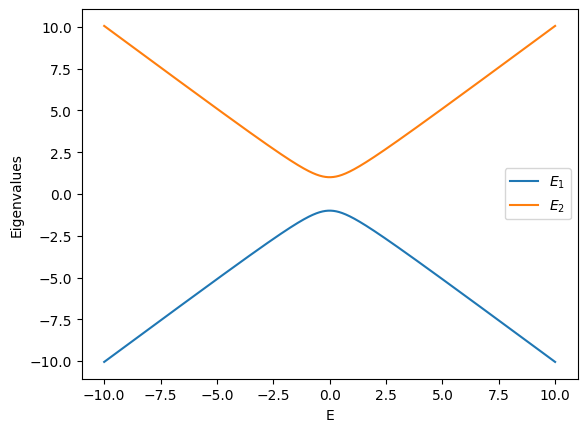

In [1109]:
def E1(E, t):
    return - np.sqrt(E**2 + t**2)

def E2(E, t):
    return np.sqrt(E**2 + t**2)

# Define T = 1MeV
t = 1

EValues = np.linspace(-10, 10, 1000)
E1Values = E1(EValues, t)
E2Values = E2(EValues, t)

plt.plot(EValues, E1Values, label="$E_1$")
plt.plot(EValues, E2Values, label="$E_2$")

plt.legend()
plt.xlabel("E")
plt.ylabel("Eigenvalues")
# plt.title("Eigenenergies of a 2x2 qubit Hamiltonian for t=1.")
plt.show()

*Figure 1* - Eigenvalues of a 2x2 qubit as a function of the values of the Hamiltonian's Diagonal H. In this case $t = 1$.

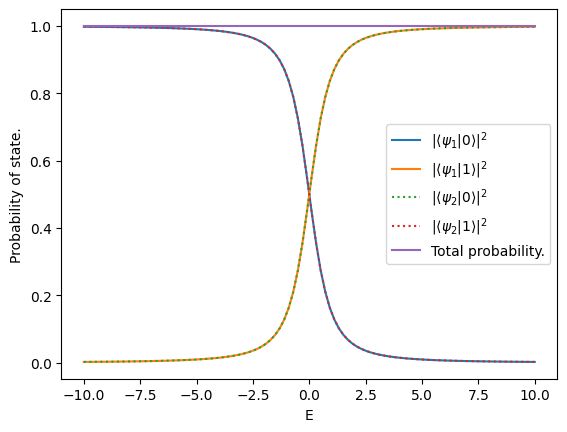

In [1110]:
def lambd(E, t):
    return np.sqrt(E**2 + t**2)

def psi1(E, t):
    v = np.array([-t, E + lambd(E, t)])
    return v / np.linalg.norm(v)

def psi2(E, t):
    v = np.array([-t, E - lambd(E, t)])
    return v / np.linalg.norm(v)

vec0 = np.array([1, 0])
vec1 = np.array([0, 1])

c1 = []
c2 = []
c3 = []
c4 = []
EValues = np.linspace(-10, 10, 100)
for E in EValues:
    t = 1
    c1.append(psi1(E, t) @ vec0)
    c2.append(psi1(E, t) @ vec1)
    c3.append(psi2(E, t) @ vec0)
    c4.append(psi2(E, t) @ vec1)

c1 = np.abs(np.asarray(c1))**2
c2 = np.abs(np.asarray(c2))**2
c3 = np.abs(np.asarray(c3))**2
c4 = np.abs(np.asarray(c4))**2

plt.plot(EValues, c1, label="$|\\langle \\psi_1 | 0 \\rangle |^2$")
plt.plot(EValues, c2, label="$|\\langle \\psi_1 | 1 \\rangle |^2$")
plt.plot(EValues, c3, label="$|\\langle \\psi_2 | 0 \\rangle |^2$", ls = ':')
plt.plot(EValues, c4, label="$|\\langle \\psi_2 | 1 \\rangle |^2$", ls = ':')
plt.plot(EValues, c1 + c3, label="Total probability.")

plt.xlabel("E")
plt.ylabel("Probability of state.")
plt.title("")
plt.legend()
plt.show()

*Figure 2* - Probability of the 1st and 2nd order wave-functions as a function of the value of the Hamiltonian's diagonal H.

## Part ii) - Engineering the Hamiltonian for a Metal Oxide Semiconductor device.

In [1111]:
### Mesh
def constructSpace(Np, a = 3e-7): # Units should be in meters. 
    position = a * np.linspace(0, 1, Np) 
    potential = np.zeros(Np)
    space = np.stack((position, potential), axis = 1)
    space.T[0] = space.T[0] - space.T[0].max()/2

    return space

### Initialise the system
def resetPotential(space):
    space.T[1] = 0

def sdPotential(space, x1, alpha): # Alpha should be in eV/m^2
    x = space.T[0]

    space.T[1] = space.T[1] + alpha * (np.abs(x) - x1)**2 

def ddPotential(space, x1, x2, alpha):
    x = space.T[0]

    potentialLeft = alpha * (x - x1)**2
    potentialRight = alpha * (x - x2)**2

    space.T[1] = space.T[1] + np.minimum(potentialLeft, potentialRight)

### Solve the system.
def constructHamiltonian(space, m = m_e*0.2):
    Np = space.shape[0]
    x = space.T[0]
    U = space.T[1]
    a = x[1] - x[0] # Units of meters. 
    
    t = hbar*hbar / (2*m*a*a) / elementary_charge # Units of eV

    onDiag = 2*t * np.ones(Np) + U
    offDiag = -t * np.ones(Np-1)

    H = np.diag(onDiag) + np.diag(offDiag, 1) + np.diag(offDiag, -1)

    return H

def solveHamiltonian(H):
    energy, eigenState = eigh(H)
    return energy, eigenState

def normalise(psi):
    return psi / np.linalg.norm(psi)


## Results and Discussion

### Part i) - Solution of the 2x2 bit Hamiltonian.

A seen in figure 1, the difference between the eigen-energies reaches a minimum as the diagonal of the 2x2 Hamiltonian reaches 0, $E = 0$. For values of $|E|$ further away from the origin, the gradient of the eigen-energies as a function of $E$ becomes linear, whereas closer to the origin, they behave non-linearly. 

As seen in figure 2, there is an equivalent probability of finding $\Psi_1$ and $\Psi_2$ in opposing states. This is expected from the theory, where $|\langle \Psi_1 | 0 \rangle|^2 = |\langle \Psi_2 | 1 \rangle|^2$.

### Part ii) - Engineering the Hamiltonian for a Metal Oxide Semiconductor device.
There are no results to discuss from this section as the solution of the 1D time independent Hamiltonian will be solved in their respective sections B and C. The function of this code is to construct a space containing both the position $X$[m] of each node, and the corresponding potential $U$[eV] at each node. Applying a potential to the space adjusts the potential of each node in accordance to a specific potential function. The constructHamiltonian and solveHamiltonian functions construct the hamiltonian according to the background, and solves for its eigen-values and eigen-states. 


# Part B
This section of the report will analyse the wave-function produced by a single quantum dot, created through a parabolic potential of curvature $\alpha$ centered at position $x_1$ [1],
$$V(x) = \alpha (x - x_1)^2$$

The aim of the code below, and part B as a whole is to understand the relationship between the energy splitting, or energy difference between the ground and excited state wave-function, $\Delta E = E_2 - E_1$, and to determine a curvature coefficient $\alpha$ which engineers a splitting energy of $\Delta E = 4\text{meV}$. This will be achieved through constructing an array of alpha values which span the $4\text{meV}$ splitting energy, and then by using linear interpolation, numerically determine what $\alpha$ achieves the desired splitting energy.

## Part i) - Analysis of the impact of $\alpha$ on the splitting energy of the energy of the two lowest wave-functions of a SQD potential well.

In [1112]:
x1 = 0

energyGap = []
space = constructSpace(1000)
minAlpha = 1e12
maxAlpha = 5e13
alphaList = np.linspace(minAlpha, maxAlpha, 1000)
for alpha in alphaList:
    resetPotential(space)
    sdPotential(space, x1, alpha)

    X = space.T[0]
    U = space.T[1]

    H = constructHamiltonian(space)
    W, V = solveHamiltonian(H)

    energyGap.append(W[1] - W[0])

energyGap = np.asarray(energyGap)


6.171377794578263


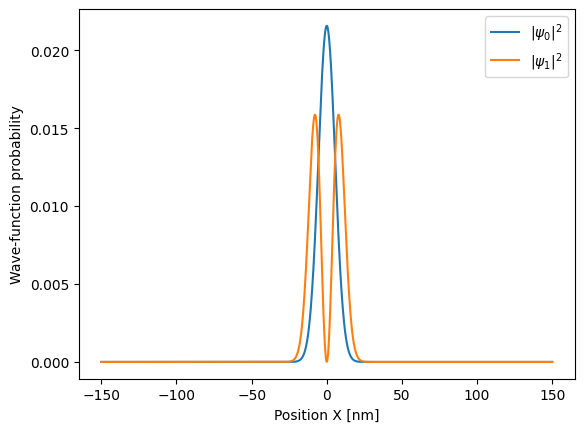

In [1113]:
# Plot 0th and 1st order wave functions
X = space.T[0] * m_TO_nm # Convert space to nm
U = space.T[1] * eV_TO_meV
energyGap = energyGap * eV_TO_meV # Convert energy to meV
alphaList = alphaList * eV_TO_meV / m_TO_nm**2

psi1 = normalise(V[:, 0])
psi2 = normalise(V[:, 1])
Psi1 = psi1 * psi1
Psi2 = psi2 * psi2

print(energyGap[-1])
plt.figure()
plt.plot(X, Psi1, label="$|\\psi_0|^2$")
plt.plot(X, Psi2, label="$|\\psi_1|^2$")
plt.xlabel("Position X [nm]")
plt.ylabel("Wave-function probability")
plt.legend()
plt.show()

*Figure 3* - Probability distribution of the two lowest energy wave-functions for $\alpha = 0.05\text{meV/nm}^2$. 

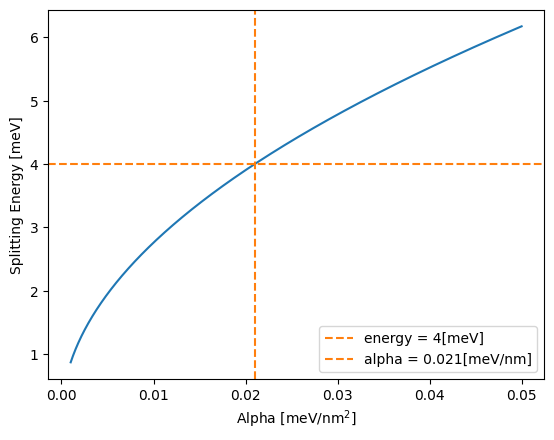

Alpha required to achieve 4meV splitting energy = 0.0210[meV/nm^2]


In [1114]:
energy = 4 # [meV]

# Determine value to achieve alpha=4meV
alphaBeforeIndex = np.where(np.diff(np.sign(energyGap - energy)))[0]
alphaAfterIndex = alphaBeforeIndex+1

energyBefore = energyGap[alphaBeforeIndex]
energyAfter = energyGap[alphaAfterIndex]
alphaBefore = alphaList[alphaBeforeIndex]
alphaAfter = alphaList[alphaAfterIndex]

gradient = (alphaBefore-alphaAfter)/(energyBefore - energyAfter)
alphaFunc = lambda en: gradient * (en - energyBefore) + alphaBefore

alpha = alphaFunc(energy)

plt.plot(alphaList, energyGap)
plt.xlabel("Alpha [meV/nm$^2$]")
plt.ylabel("Splitting Energy [meV]")
plt.axhline(y=energy, c = 'tab:orange', ls = '--', label=f"energy = {energy}[meV]")
plt.axvline(x=alpha, c = 'tab:orange', ls = '--', label=f"alpha = {alpha[0]:.3f}[meV/nm]")
plt.legend()
plt.show()

print(f"Alpha required to achieve 4meV splitting energy = {alpha[0]:.4f}[meV/nm^2]")

*Figure 4* - Energy gap as a function of Alpha. The alpha required achieve an energy of $\Delta E=4\text{meV}$ was numerically determined at $\alpha = 0.021\text{meV/nm}^2$

In [1115]:
space = constructSpace(1000)
x1 = 0

alpha = 0.0210 * m_TO_nm**2 / eV_TO_meV

sdPotential(space, x1, alpha)
H = constructHamiltonian(space)
W, V = solveHamiltonian(H)

X = space.T[0]
U = space.T[1]

X = X * m_TO_nm
U = U * eV_TO_meV

Psi0=np.multiply(V[:,0],V[:,0])

print(f"FWHM of Psi0 {fwhm(X, Psi0)}nm")
print(f"FWHM of Psi1 {fwhm(X, Psi1)}nm")

FWHM of Psi0 15.915915915915948nm
FWHM of Psi1 12.912912912912896nm


## Part ii) - Analysis of mesh related errors.

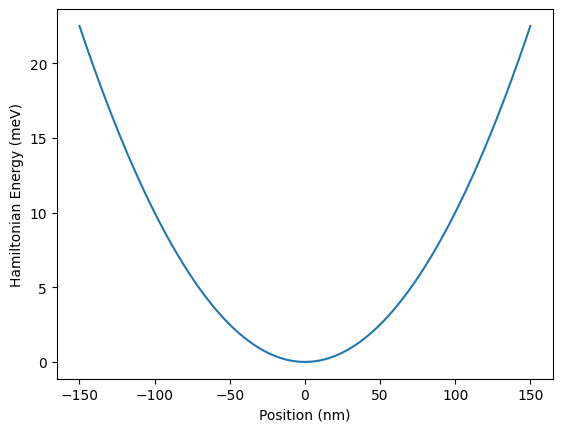

In [1116]:
space = constructSpace(1000) # The space constructed is in units of meters. 

# Position the single dot in the center.
x1=0

alpha = minAlpha
sdPotential(space, x1, alpha) # Units of eV/m

H = constructHamiltonian(space)
W, V = solveHamiltonian(H)

X = space.T[0]
U = space.T[1]

X = X * m_TO_nm
U = U * eV_TO_meV

plt.plot(X, U)
plt.xlabel("Position (nm)")
plt.ylabel("Hamiltonian Energy (meV)")
plt.show()

*Figure 5* - SQD potential well used to determine mesh parameters.

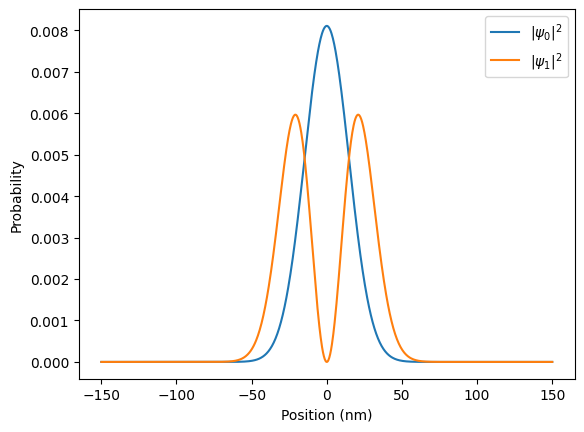

In [1117]:

# Plot 0th and 1st order wave functions
psi1 = normalise(V[:, 0])
psi2 = normalise(V[:, 1])
Psi1 = psi1 * psi1
Psi2 = psi2 * psi2

plt.figure(2)
plt.plot(X, Psi1, label="$|\\psi_0|^2$")
plt.plot(X, Psi2, label="$|\\psi_1|^2$")

plt.xlabel("Position (nm)")
plt.ylabel("Probability")
plt.legend()
plt.show()


*Figure 6* - Corresponding wave functions used to determine mesh parameters of the SQD potential well.

In [1118]:
print(f"FWHM of |Psi0|^2: {fwhm(X, Psi0)}nm")
print(f"FWHM of |Psi1|^2: {fwhm(X, Psi1)}nm")

# Make the required mesh size 6 times the maximum FWHM
psi0FWHM = fwhm(X, Psi0)
psi1FWHM = fwhm(X, Psi1)
maxFWHM = max([psi0FWHM, psi1FWHM])
requiredDomainSize = 4 * maxFWHM

print(f"Required domain size: {requiredDomainSize}nm")


FWHM of |Psi0|^2: 15.915915915915948nm
FWHM of |Psi1|^2: 34.5345345345345nm
Required domain size: 138.138138138138nm


## Results and Discussion 

### Part i) - Analysis of the impact of $\alpha$ on the splitting energy of the energy of the two lowest wave-functions of a SQD potential well.
It was observed that with increasing alpha, the energy gap between the ground and excited states increased at a decreasing rate. This indicates, that with an increasing alpha, the splitting energy increases, but at a degrading rate. It was found that the alpha required to achieve $4\text{meV}$ of splitting energy was $\alpha = {0.0210\text{meV/nm}^2}$. 

In a physical device this could be achieved by attaching a set of electrodes to a lattice (in this case a Si lattice), and controlling their potential to produce a net parabolic potential over the lattice.

For the quantum state to operate, the thermal energy must be lower than the splitting energy,
$$k_b T << E_{\text{split}}$$
$$k_b T << 4\text{meV}$$
$$T << 46419.86... \text{mK}$$
$$T << 46.4 \text{K}$$

### Part ii) - Analysis of mesh related errors.
There were three different mesh related errors considered,
1. Artificial confinement of the wavefunction due to a small simulation domain 

As previously discussed, a lower alpha reduces how confined the quantum state is, therefore by simulating the SQD at the lowest alpha iterated over ($\alpha = 0.001\text{meV/nm}^2$), and finding the spread of the ground and excited wave-functions, an appropriate lattice size for the simulation domain can be chosen. This was chosen such that the FWHM of the most spread wave-function $\psi_0$ occupied 1/4th of the total simulation domain. 

2. A coarse mesh inaccurately meshing the wave-function.

The number of points in the mesh was set to 1000 to generate a fine mesh in comparison to the size of the wave-functions, whilst balancing solution time. A proper analysis of mesh quality would require a mesh convergence study, for example, analyzing the energies of the ground and excited wave-functions as a function of how refine the mesh is.

3. To large of an iteration size for the alpha calculation.

The number of iterations was set to 1000 to approximate alpha accurately, whilst balancing solution time. This was concluded as appropriate through the use of linear interpolation to determine the required $\alpha$ value.. Similar to the degree of mesh refinement, a convergence analysis of iteration size is required, however is outside the scope of this assignment. 


### Part iii) - Comparison to the analytic 2x2 qubit Hamiltonian from Part A.
A quantum dot is known as an artificial atom, due to its similarity with properties of an atom, specifically, how the confinement of the quantum state, forcing it into a small range of energy levels is physically similar to that of a single atom which exhibit discrete energy levels through electron orbitals.

This analysis assumes a SQD at $\alpha = 0.0210\text{meV/nm}^2$.

It was found that the FWHM of the ground state wave-function was $16.2\text{nm}$. Compared to the Bohr radius of the ground state of the Hydrogen atom ($0.0529\text{nm}$), the radius of the ground state of the SQD is roughly 306.2 times larger [1]. 

If the silicone atoms in the 1D crystal chain are spaced by $0.543\text{nm}$, the ground state of the SQD spans 29.8 atoms. 

# Part C - The Double Quantum Dot
The double quantum dot (DQD) is a quantum state confined by the following potential [1],
$$
V_{\text{DQD}} (X) = \text{min}\left[ \alpha (x-x_1)^2, \alpha (x-x_2)^2 \right]
$$
This potential produces two symmetric parabolic wells of curvature $\alpha$ separated by some radius $R=|x_2-x_1|$.

Due to the potential barrier separating the two wells, for large $R$, the quantum states are more likely to be isolated from each other, however for small $R$, it is expected that tunnelling will occur between the two wells, producing two quantum states that are not isolated from each other.

Additionally, the impact of a linear potential, or detuning bias will be applied to the DQD potential well of the form [1],
$$
V_{detune} (X) = F x
$$

The following code seeks to understand the relationship between the well spacing $R$, and the strength of interaction between the two quantum dots and concluding suggestion for an $R$ to allow for a qubit to operate in parts i) and ii). In part iii), a linear detuning bias is applied to the potential well and its impacts on the lowest two wave-functions and their corresponding energy will be analysed, in addition to a suggestion for a value F which most optimally permits the operation of a qubit.


## Part i) Qualitative impacts of changing $R$.

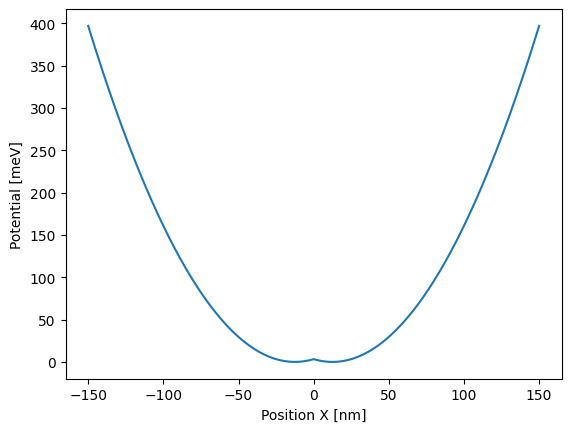

In [1119]:
space = constructSpace(1000)

R = 0.25e-7
X1 = -R/2
X2 = R/2

alpha = 0.0210 * (eV_TO_meV * m_TO_nm **(-2))**(-1)
ddPotential(space, X1, X2, alpha)

H = constructHamiltonian(space)
W, V = solveHamiltonian(H)

X = space.T[0]
U = space.T[1]

X = X * m_TO_nm
U = U * eV_TO_meV

plt.plot(X, U, label="DQD Potential Well")
plt.xlabel("Position X [nm]")
plt.ylabel("Potential [meV]")
plt.show()

*Figure 7* - Double quantum dot potential well used to analyse a strong interaction between quantum dots.

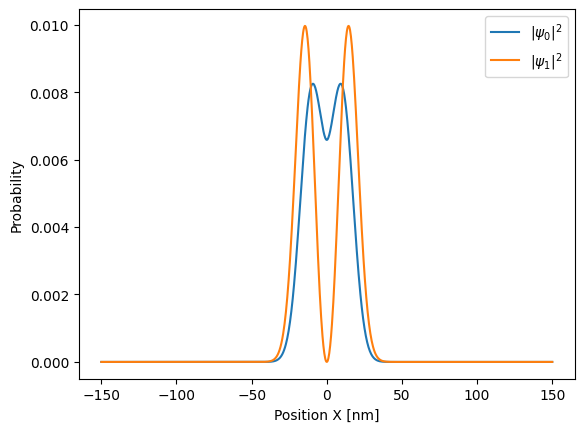

In [1120]:

# Calculate and plot two lowest energy wave-functions
psi1 = normalise(V[:, 0])
psi2 = normalise(V[:, 1])
Psi1 = psi1 * psi1
Psi2 = psi2 * psi2

plt.plot(X, Psi1, label="$|\\psi_0|^2$")
plt.plot(X, Psi2, label="$|\\psi_1|^2$")
plt.xlabel("Position X [nm]")
plt.ylabel("Probability")
plt.legend()
plt.show()


*Figure 8* - Double quantum dot potential well with strong quantum dot interaction wave-functions.

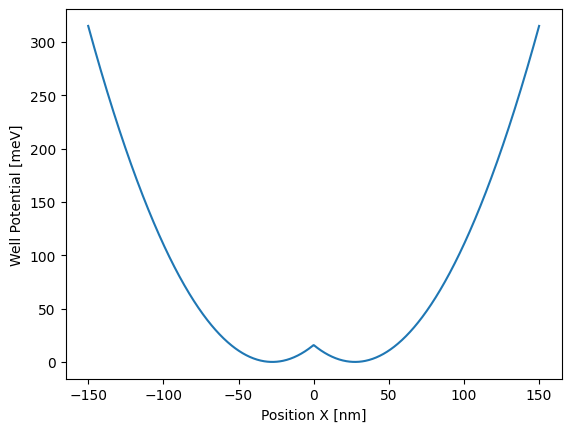

In [1121]:
space = constructSpace(1000)

R = 5.5e-8
X1 = -R/2
X2 = R/2

alpha = 0.0210 * (eV_TO_meV * m_TO_nm **(-2))**(-1)
ddPotential(space, X1, X2, alpha)

H = constructHamiltonian(space)
W, V = solveHamiltonian(H)

X = space.T[0]
U = space.T[1]

X = X * m_TO_nm
U = U * eV_TO_meV

plt.plot(X, U, label="DQD Potential Well")
plt.xlabel("Position X [nm]")
plt.ylabel("Well Potential [meV]")
plt.show()


*Figure 9* - Double quantum dot potential well used to analyse a weak interaction between quantum dots.

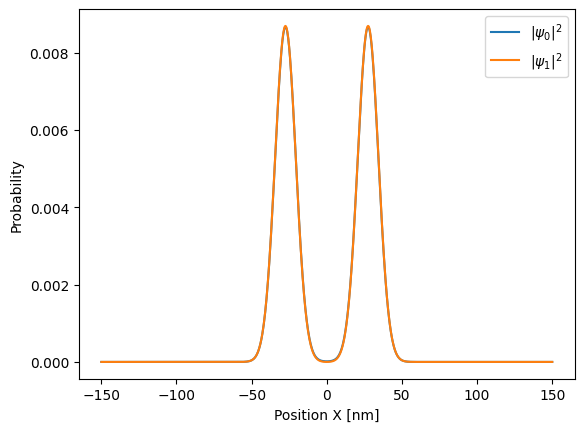

In [1122]:
# Calculate and plot two lowest energy wave-functions
psi1 = normalise(V[:, 0])
psi2 = normalise(V[:, 1])
Psi1 = psi1 * psi1
Psi2 = psi2 * psi2

plt.plot(X, Psi1, label="$|\\psi_0|^2$")
plt.plot(X, Psi2, label="$|\\psi_1|^2$")
plt.xlabel("Position X [nm]")
plt.ylabel("Probability")
plt.legend()
plt.show()

*Figure 10* - Double quantum dot potential well with weak quantum dot interaction wave-functions.

## Part ii) - Determining a value $R$ to operate a qubit effectively.

In [ ]:
Np = 1000

# Define potential parameters
R = np.linspace(0, 8e-8, Np)
alpha = 0.0210 * m_TO_nm**2 / eV_TO_meV

energyGap = []
space = constructSpace(Np)
for wellGap in R:
    x1 = -wellGap/2
    x2 = wellGap/2

    resetPotential(space)
    ddPotential(space, x1, x2, alpha)

    H = constructHamiltonian(space)
    W, V = solveHamiltonian(H)

    
    energyGap.append(W[1] - W[0])

energyGap = np.asarray(energyGap)

R = R * m_TO_nm
energyGap = energyGap * eV_TO_meV

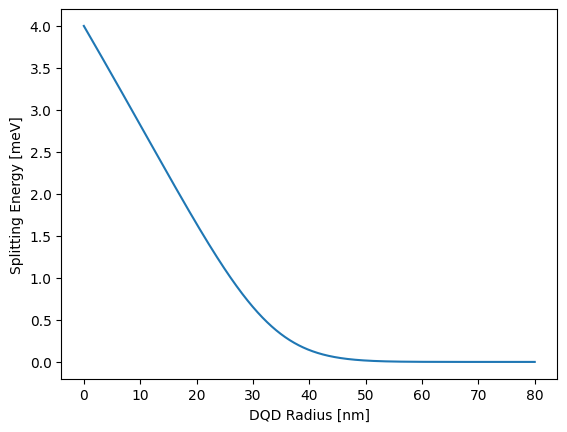

In [ ]:
plt.plot(R, energyGap)
plt.xlabel("DQD Radius [nm]")
plt.ylabel("Splitting Energy [meV]")
# plt.legend()
plt.show()

*Figure 11* - Relationship between the splitting energy of the lowest two wave-functions as a function of the DQD radius $R$.

## Part iii) - Qualitatively understanding the detuning bias, and selecting $F$ to operate a qubit.

In [ ]:
def customPotential(space, potentialFunction = lambda x: x * 0):
    X = space.T[0]

    space.T[1] = space.T[1] + potentialFunction(X)

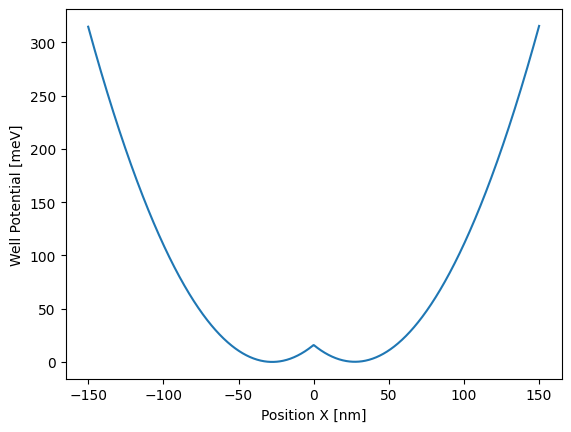

In [ ]:
R = 55e-9
X1 = -R/2
X2 = R/2
energy = 4e-3
# alpha = alphaFunc(energy)

F = 2500 
electricField = lambda x: F * x

alpha = 0.0210 * m_TO_nm**2 / eV_TO_meV

# sdPotential(space, 0, 100)
space = constructSpace(1000)
ddPotential(space, X1, X2, alpha)
customPotential(space, electricField)

# Construct and solve the Hamiltonian.
H = constructHamiltonian(space)
W, V = solveHamiltonian(H)

# Extract X and U parameters of the space and plot.
X = space.T[0]
U = space.T[1]

X = X * m_TO_nm
U = U * eV_TO_meV

plt.plot(X, U, label="DQD Potential Well")
plt.xlabel("Position X [nm]")
plt.ylabel("Well Potential [meV]")
# plt.title("DQD Quantum well with an additional positive \ngradient uniform electric field.")
plt.show()


*Figure 12* - DQD potential well used to analyse the impacts of a positive gradient detuning bias.

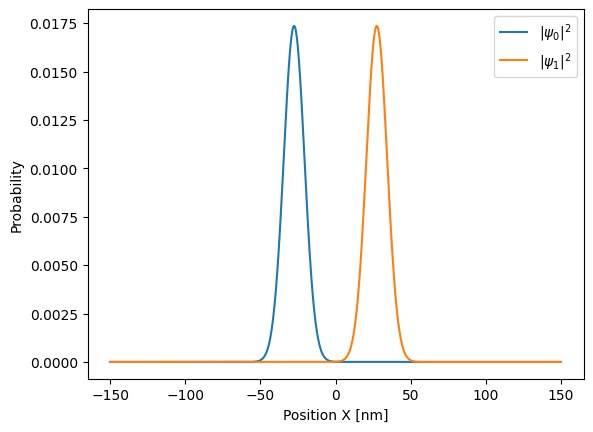

Splitting energy: 0.00013755991386540023


In [ ]:

# Calculate and plot two lowest energy wave-functions
psi1 = normalise(V[:, 0])
psi2 = normalise(V[:, 1])
Psi1 = psi1 * psi1
Psi2 = psi2 * psi2

plt.plot(X, Psi1, label="$|\\psi_0|^2$")
plt.plot(X, Psi2, label="$|\\psi_1|^2$")
plt.xlabel("Position X [nm]")
plt.ylabel("Probability")
# plt.title("Probability distribution of the two lowest order wave-functions \nin a DQD well with a positive gradient uniform electric field.")
plt.legend()
plt.show()

print(f"Splitting energy: {W[1] - W[0]}")

*Figure 13* - Lowest two wave-functions of the double quantum dot potential well with a linear detuning bias of $V(x) = 2500x$.

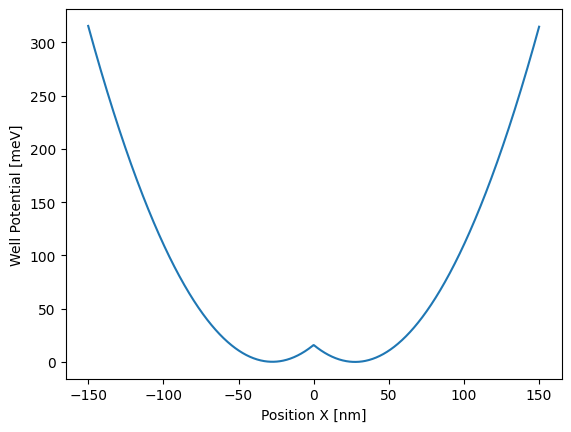

In [ ]:
R = 55e-9
X1 = -R/2
X2 = R/2
energy = 4e-3

F = -2500
electricField = lambda x: F * x

alpha = 0.0210 * m_TO_nm**2 / eV_TO_meV

space = constructSpace(1000)
ddPotential(space, X1, X2, alpha)
customPotential(space, electricField)

# Construct and solve the Hamiltonian.
H = constructHamiltonian(space)
W, V = solveHamiltonian(H)

# Extract X and U parameters of the space and plot.
X = space.T[0]
U = space.T[1]

X = X * m_TO_nm
U = U * eV_TO_meV

plt.plot(X, U, label="DQD Potential Well")
plt.xlabel("Position X [nm]")
plt.ylabel("Well Potential [meV]")
# plt.title("DQD Quantum well with an additional negative \ngradient uniform electric field.")
plt.show()

*Figure 14* - DQD potential well used to analyse the impacts of a negative gradient detuning bias.

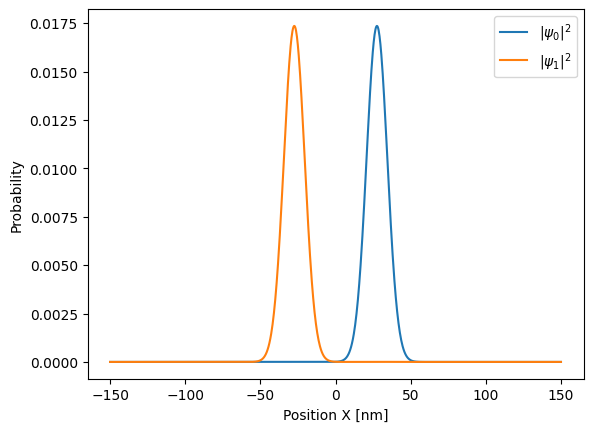

Splitting energy: 0.00013755991386540651


In [ ]:
# Calculate and plot two lowest energy wave-functions
psi1 = normalise(V[:, 0])
psi2 = normalise(V[:, 1])
Psi1 = psi1 * psi1
Psi2 = psi2 * psi2

plt.plot(X, Psi1, label="$|\\psi_0|^2$")
plt.plot(X, Psi2, label="$|\\psi_1|^2$")
plt.xlabel("Position X [nm]")
plt.ylabel("Probability")
plt.legend()
# plt.title("Probability distribution of the two lowest order wave-functions \nin a DQD well with a negative gradient uniform electric field.")
plt.show()

print(f"Splitting energy: {W[1] - W[0]}")


*Figure 15* - Lowest two wave-functions of the double quantum dot potential well with a linear detuning bias of $V(x) = -2500x$.

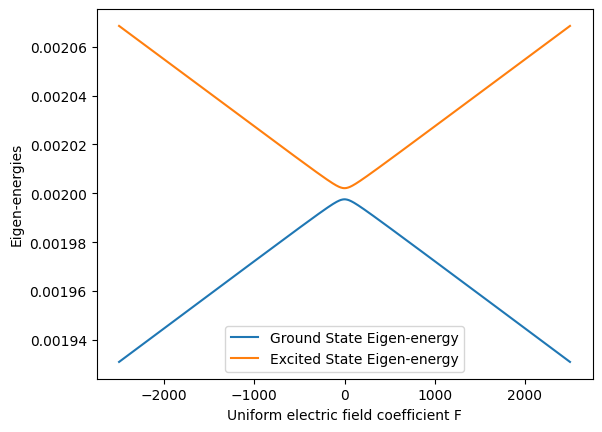

In [ ]:
R = 55e-9
X1 = -R/2
X2 = R/2
energy = 4e-3
# alpha = alphaFunc(energy)

F = 2500 
FArray = np.linspace(-F, F, 1000)

alpha = 0.0210 * m_TO_nm**2 / eV_TO_meV

# sdPotential(space, 0, 100)
space = constructSpace(1000)

eigenvalues = []
for FValue in FArray:
    resetPotential(space)
    ddPotential(space, X1, X2, alpha)
    electricField = lambda x: FValue * x
    customPotential(space, electricField)

    # Construct and solve the Hamiltonian.
    H = constructHamiltonian(space)
    W, V = solveHamiltonian(H)

    # Extract X and U parameters of the space and plot.
    X = space.T[0]
    U = space.T[1]

    eigenvalues.append([W[0], W[1]])

eigenvalues = np.asarray(eigenvalues)
groundEig = eigenvalues.T[0]
oneStEig = eigenvalues.T[1]

plt.plot(FArray, groundEig, label="Ground State Eigen-energy")
plt.plot(FArray, oneStEig, label="Excited State Eigen-energy")
plt.xlabel("Uniform electric field coefficient F")
plt.ylabel("Eigen-energies")
plt.legend()
plt.show()


*Figure 16* - Relationship between the detuning coefficient F and the energies of the two lowest wave-functions.

## Results and Discussion

### Part i) - Qualitative impacts of changing $R$.
As expected, for a small $R$ there is significant tunneling through the potential wall between the wells, leading to the two states not being independent of each other due to tunneling through the relatively low separating potential barrier at X = 0. This is clear in the comparison between figure 8 and figure 10, where the ground state wave-function exhibits significant tunneling (and therefore a strong interaction between wells) in figure 8 at a small well separation, whereas for a large well separation in figure 10, the ground state wave-function has a very low tunneling probability (and therefore a weak interaction between wells).

### Part ii) - Determining a value $R$ to operate a qubit effectively.

The spacing between the quantum dots influences the off-axis elements of the 2x2 Hamiltonian from Part A. This is due to these parameters impacting the coupling strength between the ground and excited wave-functions.

For a engineering a double quantum dot, a larger separation between the wells ($R$) is preferable as this isolates the dots, and prevents tunneling through the wall, and therefore a decrease in the degeneracy between the quantum dots. However, too large of a separation would prevent any transition between quantum states, and therefore would not be an effective model for a qubit where the controlled oscillation between quantum states is required.

Therefore, an ideal separation used henceforth is $R = 55\text{nm}$, this appears close to the start of the horizontal asymptote, balancing a close well spacing to reduce artificial confinement with a low interaction between wells.

### Part iii) - Qualitatively understanding the detuning bias, and selecting $F$ to operate a qubit.

As observed, when the sign of $F$ is changed, the occupancy of the left and right well switches from the ground and excited state, to the reverse excited and ground state respectively, and hence the detuning bias likely impacts the on-diagonal elements of the 2x2 qubit Hamiltonian from Part A. This is confirmed though the similar responses in figure 16, the influence of F on the energies of the two lowest order wave-functions, and figure 1 which explores the analytic response of the wave-function energies as a function of E, the on-diagonal parameter of the 2x2 qubit Hamiltonian.

From the simulation over the range $F = [-2500, 2500]\text{eV}$, it is observed that the qubit can be operated once the linear asymptote is approached. It appears that this safely occurs approximately at $F = \pm 500\text{eV}$.


# Part D
This part will analyze the response of the wave-function as it propagates over time when a time-dependent oscillating potential (equation below) is applied in addition to the DQD potential well [1].
$$
V(x, t) = F x \cos(\omega t)
$$

This section will both analyse the in-phase response where $\omega = \omega_R = \frac{E_1 - E_0}{\hbar}$, and the out of phase response where $\omega = 0.95 \omega_R$.


## Part i) - Resonant Rabi-Oscillations.

In [ ]:
def rabiPotential(space, t, F, omega):
    x = space.T[0]

    potential = F * x * np.cos(t * omega)

    space.T[1] = space.T[1] + potential

In [ ]:
### Initialization parameters
R = 45e-9
X1 = -R/2
X2 = R/2
energy = 4e-3

alpha = 0.0210 * (eV_TO_meV * m_TO_nm **(-2))**(-1)

### Initialise the system
space = constructSpace(1000) # This space will be used globally

F = 5000
electricField = lambda x: F * x

ddPotential(space, X1, X2, alpha)
customPotential(space, electricField)

H_init = constructHamiltonian(space)
W_init, V_init = solveHamiltonian(H_init)

Psi_0_init = V_init[:, 0].copy()
Psi_1_init = V_init[:, 1].copy()

Psi_init = [
    Psi_0_init, Psi_1_init
]

### timestep
rabiF = 5000
# rabiOmega = energy/hbar

rabiOmega = np.abs(W_init[1] - W_init[0]) / hbar
tOsc = 2*np.pi / rabiOmega
t0 = 0
t_max = 10 * tOsc
deltaTime = (t_max - t0)/1000

projections = []
timeArray = []
H = H_init # Initialise with Hamiltonian
Psi = Psi_0_init # Initialise with ground state wave-function
currentTimeStep = t0
currentIteration = 0
while currentTimeStep <= t_max:
    currentTimeStep = deltaTime * currentIteration
    timeArray.append(currentTimeStep)
    # print(currentIteration, currentTimeStep)

    ### Update potential
    resetPotential(space)
    ddPotential(space, X1, X2, alpha)
    rabiPotential(space, currentTimeStep, rabiF, rabiOmega)

    ### Construct and solve new Hamiltonian
    H_increment = constructHamiltonian(space)

    ### Setup and solution of matrices A and B
    matrixSize = H.shape[0]
    A = np.eye(matrixSize) + 1j * deltaTime / (2 * hbar) * H_increment
    B_Matrix = np.eye(matrixSize) - 1j * deltaTime / (2 * hbar) * H
    B = B_Matrix @ Psi

    Psi_increment = normalise(np.linalg.solve(A, B))

    # Projections
    p0 = np.abs(np.vdot(Psi_increment, Psi_0_init))**2
    p1 = np.abs(np.vdot(Psi_increment, Psi_1_init))**2

    projections.append([p0, p1])

    ### Increment and update
    currentIteration += 1
    H = H_increment
    Psi = Psi_increment

projections = np.asarray(projections)
timeArray = np.asarray(timeArray)

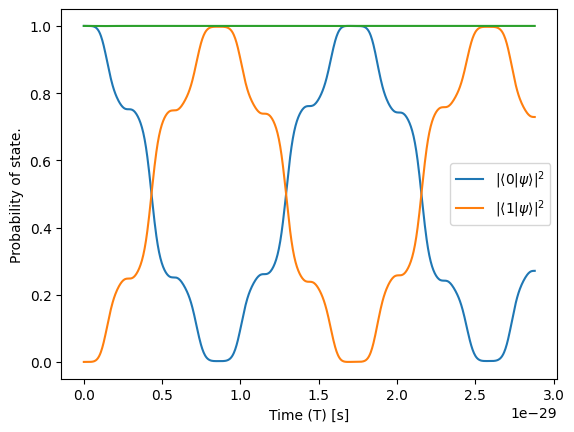

In [ ]:
plt.plot(timeArray, projections.T[0], label="|$\\langle 0 | \\psi \\rangle|^2$")
plt.plot(timeArray, projections.T[1], label="|$\\langle 1 | \\psi \\rangle|^2$")
plt.plot(timeArray, projections.T[1] + projections.T[0])
plt.xlabel("Time (T) [s]")
plt.ylabel("Probability of state.")
plt.legend()
plt.show()


*Figure 17* - In phase rabi-oscillation.

## Part ii) - Out of Phase Rabi Oscillations.

In [ ]:
### Initialization parameters
R = 45e-9
X1 = -R/2
X2 = R/2
energy = 4e-3

alpha = 0.0210 * (eV_TO_meV * m_TO_nm **(-2))**(-1)

### Initialise the system
space = constructSpace(1000) # This space will be used globally
# space_init = space.copy() # Allows reference back to init space.

F = 5000
electricField = lambda x: F * x

ddPotential(space, X1, X2, alpha)
customPotential(space, electricField)

H_init = constructHamiltonian(space)
W_init, V_init = solveHamiltonian(H_init)

Psi_0_init = V_init[:, 0].copy()
Psi_1_init = V_init[:, 1].copy()

Psi_init = [
    Psi_0_init, Psi_1_init
]

# X = (space.T[0].copy()) * m_TO_nm
# U = space.T[1].copy()
# plt.plot(X, U)
# plt.show()

# plt.plot(X, Psi_init[0] * Psi_init[0])
# plt.plot(X, Psi_init[1] * Psi_init[1])
# plt.show()

### timestep
rabiF = 5000
# rabiOmega = energy/hbar

rabiOmega = np.abs(W_init[1] - W_init[0]) / hbar 
rabiOmega = rabiOmega * 0.95
tOsc = 2*np.pi / rabiOmega
t0 = 0
t_max = 10 * tOsc
deltaTime = (t_max - t0)/1000

projections = []
timeArray = []
H = H_init # Initialise with Hamiltonian
Psi = Psi_0_init # Initialise with ground state wave-function
currentTimeStep = t0
currentIteration = 0
while currentTimeStep <= t_max:
    currentTimeStep = deltaTime * currentIteration
    timeArray.append(currentTimeStep)
    # print(currentIteration, currentTimeStep)

    ### Update potential
    resetPotential(space)
    ddPotential(space, X1, X2, alpha)
    rabiPotential(space, currentTimeStep, rabiF, rabiOmega)

    ### Construct and solve new Hamiltonian
    H_increment = constructHamiltonian(space)

    ### Setup and solution of matrices A and B
    matrixSize = H.shape[0]
    A = np.eye(matrixSize) + 1j * deltaTime / (2 * hbar) * H_increment
    B_Matrix = np.eye(matrixSize) - 1j * deltaTime / (2 * hbar) * H
    B = B_Matrix @ Psi

    Psi_increment = normalise(np.linalg.solve(A, B))


    # if currentIteration%200 == 0:
    #     waveFunc = np.abs(Psi_increment * Psi_increment)
    #     X = space.T[0].copy()
    #     plt.plot(X, waveFunc)
    #     plt.show()

    ### Calculation of 
    p0 = np.abs(np.vdot(Psi_increment, Psi_0_init))**2
    p1 = np.abs(np.vdot(Psi_increment, Psi_1_init))**2

    projections.append([p0, p1])

    ### Increment and update
    currentIteration += 1
    H = H_increment
    Psi = Psi_increment

projections = np.asarray(projections)
timeArray = np.asarray(timeArray)

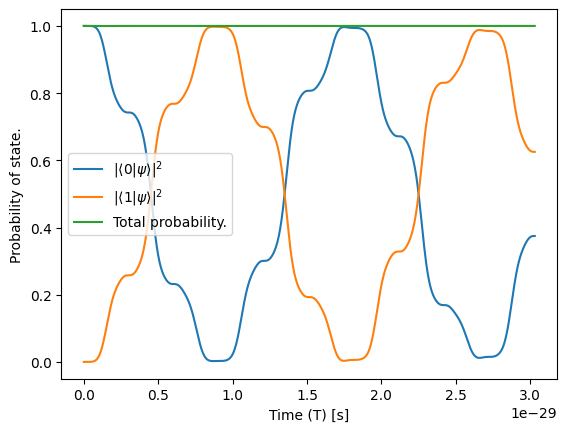

In [ ]:
plt.plot(timeArray, projections.T[0], label="|$\\langle 0 | \\psi \\rangle|^2$")
plt.plot(timeArray, projections.T[1], label="|$\\langle 1 | \\psi \\rangle|^2$")
plt.plot(timeArray, projections.T[1] + projections.T[0], label = "Total probability.")
plt.xlabel("Time (T) [s]")
plt.ylabel("Probability of state.")
plt.legend()
plt.show()

*Figure 18* - Out of phase rabi-oscillation.

## Discussion
### Part i) - Resonant Rabi-Oscillations.
As seen in figure 17, the in-phase rabi-oscillation, the wave-function projections on the initial ground and excited state oscillated periodically between 1 and 0. 

When selecting parameters of the system, it was found that using a well spacing of $R = 55\text{nm}$ which isolated the ground and excited state produced a very slow oscillation between the left and right hand well when compared to the rabi-oscillation. This prompted the well gap $R = 45\text{nm}$. Similarly, increasing the magnitude of the rabi-oscillation $F$ significantly above what was found to be optimal in part C allowed for a more clear oscillation as this increased the drive for the ground and excited wave-functions to swap wells.

To ensure convergence, a small timestep that divided the time range into 1000 divisions was used, and for the dimensions of the well, the suggested parameters from parts B and C were used to minimize mesh related errors which have been previously discussed.

### Part ii) - Out of Phase Rabi Oscillations.
In the comparison between in-phase Rabi-oscillation (figure 17) and the out of phase Rabi-oscillation (figure 18), it is clear that the out of phase oscillation produces some beat frequency, as the peaks of $|\langle0|\phi\langle|^2$ and $|\langle0|\phi\langle|^2$ slowly grow closer to the centerline (probability = 0.5) in figure 18. This is different from the in-phase oscillation (figure 17) where the peaks continue to intersect $P=1,0$.


# Extension - Mesh optimisation.
So far, the mesh used for analysis has had a linear spacing over $X$. Although this is effective for fast analysis of simple potential wells, for larger systems where a fine mesh over a large domain is required, the increased solution time may be prohibitive.

This section seeks to provide a basic mesh analysis for a simple SQD potential well case, using the wave-number of a spatially spread wave-function as a monitor for mesh refinement through equidistribution [3].


In [ ]:
def localWaveNumber(space, E_estimate, m, spread = 0, epsilon_factor = 1):
    U = space.T[1].copy()
    k2 = np.maximum(2 * m * (E_estimate - U) / hbar**2 + spread, 0)
    k = np.sqrt(k2)
    epsilon = epsilon_factor * np.max(k)

    return k + epsilon

def equidistibute(space, monitor):
    X = space.T[0].copy()
    Np = len(X)

    j = 1
    # node = X[j]
    S = np.zeros(Np)
    for j in range(1, Np+1):
        S[j-1] = np.trapz(monitor[:j], X[:j])
    
    S_total = S[-1]
    
    target = np.linspace(0, S_total, Np)
    
    newPosition = np.interp(target, S, X)
    newPotential = np.zeros(Np)

    newSpace = np.stack((newPosition, newPotential), axis = 1)

    return newSpace

# As we now have a non-linear mesh, we have to construct a non-linear hamiltonian
def constructNonLinHamiltonian(space, m):
    Np = space.shape[0]
    X = space.T[0].copy()
    U = space.T[1].copy()
    a = np.diff(X)
    
    t = hbar**2 / (2 * m * a**2) / elementary_charge

    onDiag = np.zeros(Np)
    onDiag[0] = t[0] + t[0]
    onDiag[-1] = t[-1] + t[-1]
    onDiag[1:-1] = t[:-1] + t[1:]
    onDiag += U

    offDiag = -t

    H = np.diag(onDiag) + np.diag(offDiag, 1) + np.diag(offDiag, -1)

    return H

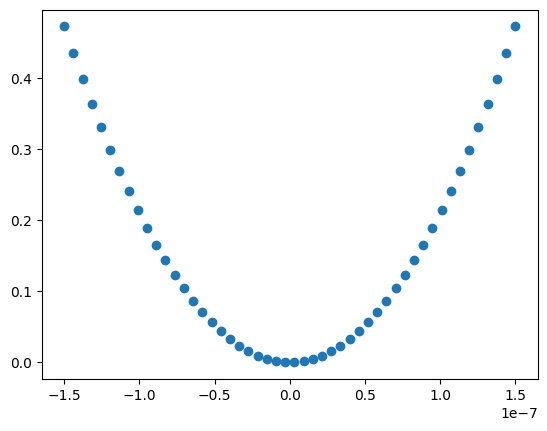

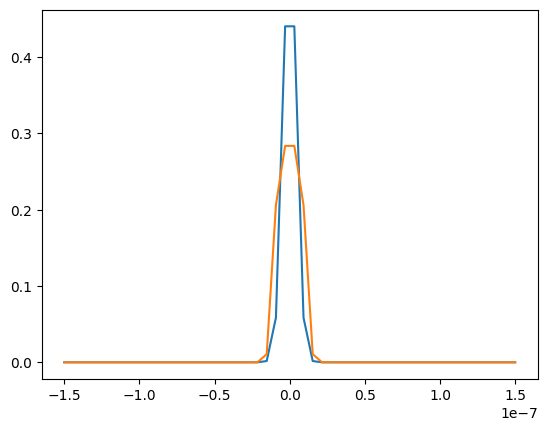

In [ ]:
space_lin = constructSpace(50)
alpha = 0.0210 * (eV_TO_meV * m_TO_nm **(-2))**(-1)
sdPotential(space_lin, 0, alpha)

X_lin = space_lin.T[0].copy()
U_lin = space_lin.T[1].copy()
X_lin = X_lin * m_TO_nm
U_lin = U_lin * eV_TO_meV

plt.scatter(X_lin, U_lin)
plt.xlabel("Position X [nm]")
plt.ylabel("Well Potential [meV]")
plt.show()

H_lin = constructNonLinHamiltonian(space_lin, m=m_e)
W_lin, V_lin = solveHamiltonian(H_lin)

Psi1_lin = V_lin[:, 0]*V_lin[:, 0]
Psi2_lin = V_lin[:, 1]*V_lin[:, 1]
plt.plot(X_lin, Psi1_lin, label="$|\\psi_0|^2$")
plt.plot(X_lin, Psi2_lin, label="$|\\psi_0|^2$")
plt.xlabel("Position X [nm]")
plt.ylabel("Probability")
plt.legend()
plt.show()

*Figure 19* - A coarse linear mesh of the 1D SQD potential well and the corresponding two lowest energy wave-functions.

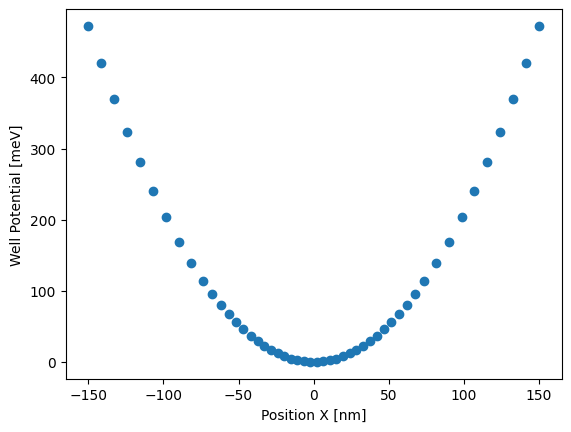

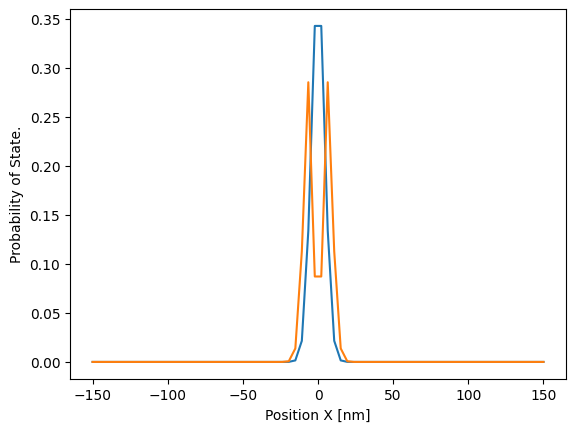

In [ ]:
# Analyse the a spread wave-function.
E = W_lin[25]
monitor = localWaveNumber(space_lin, E, m = m_e)
space_opt = equidistibute(space_lin, monitor)
sdPotential(space_opt, 0, alpha)

X_opt = space_opt.T[0].copy()
U_opt = space_opt.T[1].copy()
X_opt = X_opt * m_TO_nm
U_opt = U_opt * eV_TO_meV
plt.scatter(X_opt, U_opt)
plt.xlabel("Position X [nm]")
plt.ylabel("Well Potential [meV]")
plt.show()

H_opt = constructNonLinHamiltonian(space_opt, m = m_e)
W_opt, V_opt = solveHamiltonian(H_opt)

Psi1_opt = V_opt[:, 0]*V_opt[:, 0]
Psi2_opt = V_opt[:, 1]*V_opt[:, 1]

plt.plot(X_opt, Psi1_opt, label="$|\\psi_0|^2$")
plt.plot(X_opt, Psi2_opt, label="$|\\psi_1|^2$")
plt.xlabel("Position X [nm]")
plt.ylabel("Probability")
plt.legend()
plt.show()

*Figure 20* - An optimized coarse mesh of the 1D SQD potential well and the corresponding two lowest energy wave-functions.

## Discussion
As seen in the comparison between figures 19 and 20, the coarse linear mesh is unable to clearly resolve the peaks in the excited wave-function, whereas the optimised mesh is able to resolve the individual peaks to a finer detail.


# Conclusion

This report numerically investigated charge qubits modelled as quantum dots in a 1D silicon lattice through a finite difference mesh under a time-independent Schrodinger equation, and Crank Nicholson time-stepping for the time-dependent Schrodinger equation. Throughout the report, the numeric solutions were compared back to a analytical solution of the 2x2 qubit Hamiltonian, solved in part A.

In Part A, the 2x2 qubit Hamiltonian was analytically solved to determine the minimum splitting energy occurs at $\Delta E= 2t$, and demonstrate the transition between the two wave-functions between states $|0\rangle$ and $|1\rangle$. Additionally, this section included all of the functions required to mesh a 1D space, and analyze the respective Hamiltonian numerically. 

In Part B, the finite difference method was applied to a single quantum dot (SQD) parabolic potential. Through the analysis of the curvature parameter $\alpha$ on the splitting energy, it was determined that to obtain a splitting energy $\Delta E=4\text{meV}$, a curvature of $\alpha = 0.0210 \text{meV/nm}^2$ was required. It was additionally discussed that a temperature far below 46.4K was required for the operation of the qubit to prevent thermal effects.

In Part C, the double quantum dot (DQD) system was analyzed. It was qualitatively shown that for a small well spacing, a large degree of tunneling occurred in the ground state, while for a large well spacing the quantum dots were isolated as tunneling was suppressed. Through the analysis of well separation on the splitting energy, it was found that a spacing of $R = 55nm$ optimized a balance between isolation and residual interactions. The detuning magnitude $F$ was shown to isolate the ground and excited wave-functions to either the $|L\rangle$ or $|R\rangle$ well, where $F = 500\text{eV}$ was determined as an optimal magnitude.

In Part D, the Crank–Nicholson method was applied to the time-dependent Schrödinger equation to simulate Rabi oscillations. Under in in-phase rabi-frequency, a periodic oscillation between the ground and excited states was observed. Under an out of phase frequency however, it was observed that a beating frequency was likely present, as the projections on the initial ground and excited state did not reach $P = 0, 1$ at their peak.

In the extension, it was shown that through De Boor's algorithm, optimization of the mesh using equidistribution allowed for the resolution of wave-functions under a coarse mesh to a level that was not achievable with a linearly spaced mesh.

Overall, this report successfully modelled a DQD qubit both with and without time dependence, using parameters determined through analysis of the response of the wave-function under different potential wells. It was also shown that through mesh refinement, the computational load of the solution could be reduced, leading to potential areas of future improvement throughout, and applications for more complex quantum systems.


# References

[1] U. P. Dept, “Computational Essay: ‘Quantum dot’ charge qubits in semiconductors.” UNSW, 2026.

[2] R. Rahman, “Eigenvalue Problems.” UNSW, 2026.

[3] P. Das and S. Natesan, “Optimal error estimate using mesh equidistribution technique for singularly perturbed system of reaction–diffusion boundary-value problems,” Applied Mathematics and Computation, vol. 249, pp. 265–277, 2014, doi: https://doi.org/10.1016/j.amc.2014.10.023.

[4] R. Rahman, “Time Dependent Problems.” UNSW, 2026.
